**Проект: Предсказание заказов такси: временные ряды**

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

**Описание проекта**

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

- Необходимо построить модель, которая будет прогнозировать количество заказов такси на следующий час.

- Значение метрики RMSE на тестовой выборке должно быть не больше 48.

Компания прислала файл с датафреймом taxi.csv количество заказов находится в столбце 'num_orders'.

**План выполнения проекта**

- Загрузить данные и выполнить ресемплирование по 1 часу

- Проанализировать их

- Разделить данные на тренировочную и тестовую выборку в соотношении 90% и 10%

- Обучить модели с подбором гиперпараметров

- Проверить модели на тестовой выборке

- Сделать выводы

**Загрузим необходимые библиотеки**

In [160]:
!pip install -q catboost

In [161]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

random_state = 4

**Шаг 1. Загрузить данные и выполнить ресемплирование по 1 часу**

In [ ]:
try:
    data = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])
except FileNotFoundError:
    try:
        data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
    except FileNotFoundError:
        data = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [163]:
# Первые 5 записей
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Исследуем общую информацию о датасете методом info() и describe()

In [164]:
# Общая информация
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [165]:
# Статистика
data.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


В датасете содержится 26496 запизей в двух столбцах: datetime: дата + время, при загрузке этот столбец был определен как индекс, и num_orders: количество заказов такси

Проверим на пропуски

In [166]:
display(data.isna().sum())

num_orders    0
dtype: int64

В датасете нет пропусков.

Далее отсортируем датасет по индексу - то есть по datetime - затем проверим данные на монотонность.

In [167]:
data.sort_index(inplace=True)

In [168]:
data.index.is_monotonic

True

Данные расположены по хронологии монотонно.

Осуществим ресемплирование по 1 часу: по условию задачи нужно предсказать суммарное количество вызовов за 1 следующий час

In [169]:
data = data.resample('1H').sum()

Отобразим на графике получившийся временной ряд

<AxesSubplot:title={'center':'Заказы такси'}, xlabel='datetime'>

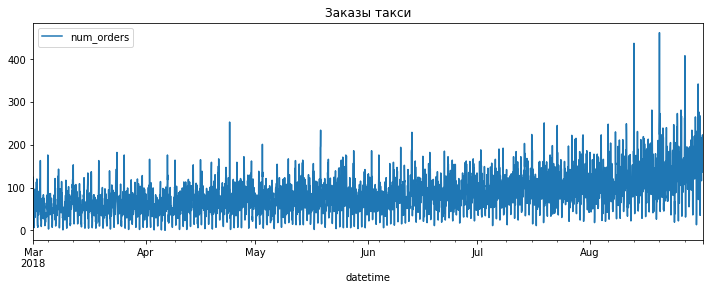

In [170]:
plt.figure(figsize=(12,4))
plt.title("Заказы такси")
data.plot(ax=plt.gca())

**Выводы**

Мы получили датасет по заказам такси за каждые 10 минут,

индексировали по столбцу datetime,

сортировали, исследовали на монотонность,

ресемплировали, суммировали количество заказов за 1 час

**Шаг 2. Анализ данных**

Посмотрим, как изменяется скользящее среднее и стандартное отклонение, сделаем вывод о стационарности временного ряда

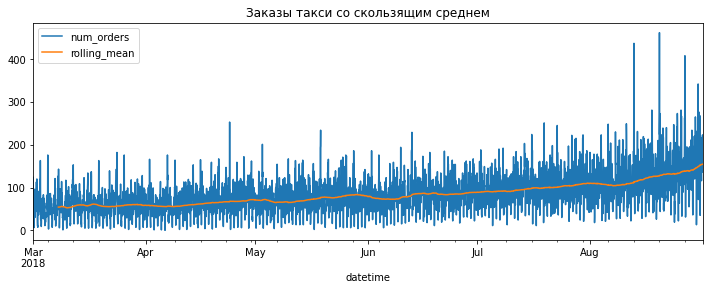

In [171]:
data['rolling_mean'] = data.rolling(24*7).mean()
plt.figure(figsize=(12,4))
plt.title("Заказы такси со скользящим среднем")
data.plot(ax=plt.gca());

In [172]:
data = data.drop(columns = ["rolling_mean"])

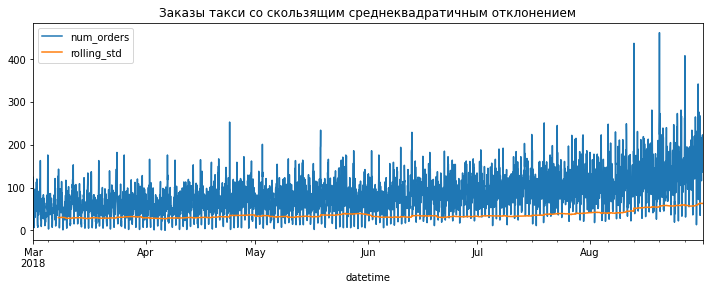

In [173]:
data['rolling_std'] = data.rolling(24*7).std()
plt.figure(figsize=(12,4))
plt.title("Заказы такси со скользящим среднеквадратичным отклонением")
data.plot(ax=plt.gca());

In [174]:
data = data.drop(['rolling_std'], axis=1)

Мы видим, что и скользящее среднее, и скользящее среднеквадратичное отклонение растут на охватываемом в датасете участке март-август, значит в строгом смысле временной ряд не является стационарным.



In [175]:
# код ревьювера
from statsmodels.tsa.stattools import adfuller

taxi = pd.read_csv("/datasets/taxi.csv", index_col=[0], parse_dates=[0]).resample('1H').sum()

ts = taxi['num_orders']
st_test = adfuller(ts, regression='ctt')

print('Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный')
if st_test[1] < 0.05:
    print('Наш ряд стационарный')
else:
    print('Ряд нестационарный')



Если значение с индексом 1 меньше P-Value, заданное нами (обычно берут 0.05), то ряд стационарный
Наш ряд стационарный


Применив тест Дики-Фуллера получаем, что ряд всё же можно назвать стационарным. Это хорошо, значит прогнозирование будет надёжнее.

Декомпозируем временной ряд: посмотрим на наличие тренда, сезонности и остатков

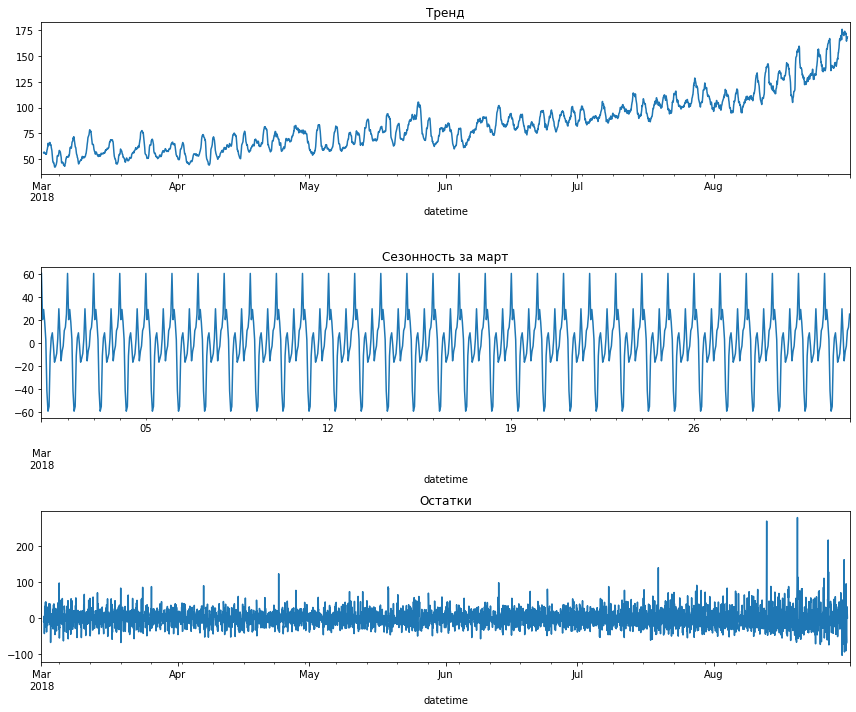

In [176]:
decomposed_data = seasonal_decompose(data)
plt.figure(figsize=(12, 10))
plt.subplot(311)

decomposed_data.trend.plot(ax=plt.gca())
plt.title('Тренд')
plt.subplot(312)
decomposed_data.seasonal['2018-03-01':'2018-03-31'].plot(ax=plt.gca())
plt.title('Сезонность за март')
plt.subplot(313)
decomposed_data.resid.plot(ax=plt.gca())
plt.title('Остатки')
plt.tight_layout()

График декомпозированного временного ряда показывает наличие тренда на увеличение числа заказов, также мы видим сезонность - колебание количества заказов в течение суток, изобразим ее на отдельном графике.

На графике остатков мы видим, что в части графика в августе остатков больше, это означает, что на тестовой выборке, которая со соответствует этому периоду, будет много данных, которые модель не объяснит, и это произойдет не по причине переобучения. 

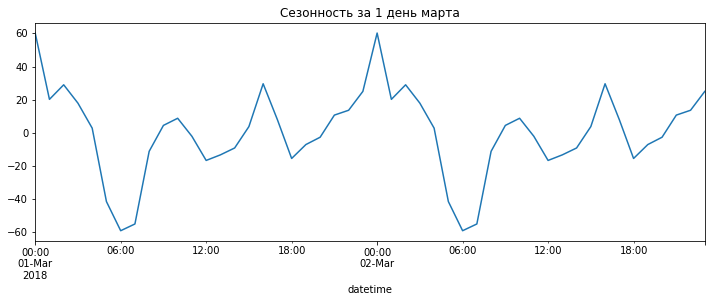

In [177]:
plt.figure(figsize=(12, 4))
decomposed_data.seasonal['2018-03-01':'2018-03-2'].plot(ax=plt.gca())
plt.title('Сезонность за 1 день марта');

На графике видно, что пик заказов в течение суток приходится на 12 ночи,
минимум - 6 утра.

Также рассмотрим сезонность по дням недели, для этого создадим копию датасета и ресемплируем ее по 1 дню.

In [178]:
data_copy = data.copy()
data_copy = data_copy.resample('1D').sum()

decomposed_days = seasonal_decompose(data_copy)

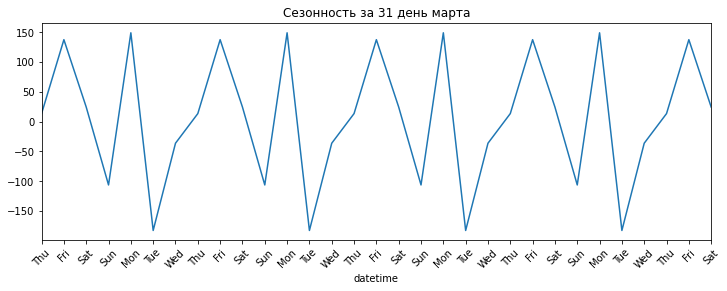

In [179]:
# Построение графика сезонности за март 2018 года
plt.figure(figsize=(12, 4))
ax = decomposed_days.seasonal['2018-03-01':'2018-03-31'].plot()
plt.title('Сезонность за 31 день марта')

# Настройка меток на оси x для отображения дня недели
date_range = data_copy['2018-03-01':'2018-03-31'].index  
# Диапазон дат для марта
ax.set_xticks(date_range)  
# Устанавливаем метки для каждого дня
# Указываем дни недели
ax.set_xticklabels(date_range.strftime('%a'), rotation=45)  

plt.show()

Мы обнаружили сезонность по дням недели, минимум приходится на вторник, пики на понедельник и пятницу, следовательно, при расчете подборе количества лагов нужно будет учитывать наличие недельной сезонности. 

**Выводы**

Мы исследовали скользящее среднее и скользящее среднеквадратичное отклонение и предположили, что датасет не стационарный,
однако проведя тест Дики-Фуллера выявили, что ряд можно назвать стационарным (привести к стационарному).

Мы декомпозировали датасет и увидели тренд на увеличение заказов на рассматриваемом в датасете участке март - август.

Мы выявили сезонность в течение суток: минимум заказов в 6 утра, максимум в 24 часа, сезонность в течение недели: минимум приходится на вторник, пики на понедельник и пятницу, сезонность в течение года на данном датасете мы определить не можем, так как он охватывает меньший период, эти выводы мы будем учитывать при создании новых признаков. 

На графике остатков мы видели, что на графике в августе остатков больше, это означает, что на тестовой выборке, которая соответствует этому периоду, будет много данных, которые модель не объяснит, и это произойдет не по причине переобучения. 

**Шаг 3. Создание тренировочной и тестовой выборок**

Для создания датасета необходимо добавить признаки

-  день, день недели, час, извлеченные из поля даты-времени, их мы выбираем, так как они соответсвуют масштабам временных интервалов, на которых можно обнаружить сезонность по нашим данным: это дни и недели

-  значения предшествующих измерений - лаги, исходя из того, что сезонность присутствует в течение суток и в течение недели, 
лагов должно быть 24*7 = 168

- скользящее среднее


In [180]:
# Извлекаем данные из столбца даты-времени

data['day'] = data.index.day
data['dayofweek'] = data.index.dayofweek
data['hour'] = data.index.hour

# Добавляем лаги предшествующие 168 часа
for lag in range(1, 168 + 1):
    data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

# Добавляем скользящее среднее 6 часов
data['rolling_mean'] = data['num_orders'].shift().rolling(6).mean()

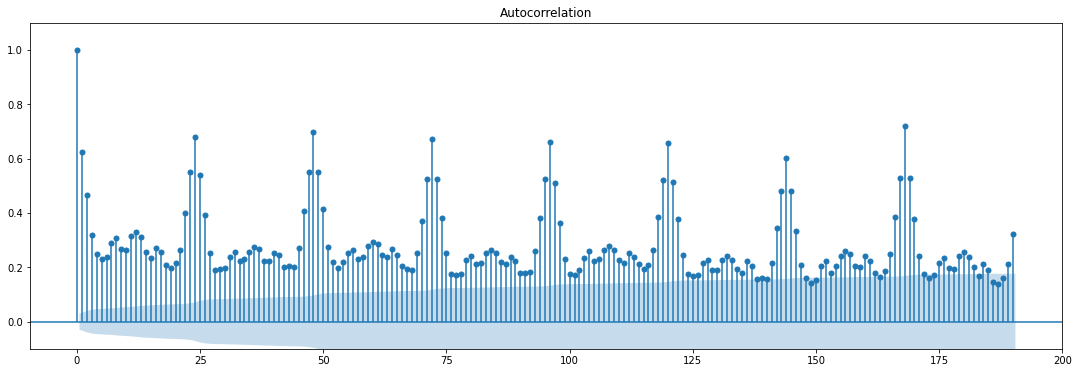

In [181]:
# Код ревьюера
from statsmodels.graphics import tsaplots

taxi = pd.read_csv("/datasets/taxi.csv", index_col=[0], parse_dates=[0]).resample('1H').sum()
ts = taxi['num_orders']

fig = tsaplots.plot_acf(ts,lags= 190)
fig.set_size_inches(18.5, 6)
plt.ylim(-.1, 1.1)
plt.show()

Удалим пропуски

In [182]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4248 entries, 2018-03-08 00:00:00 to 2018-08-31 23:00:00
Freq: H
Columns: 173 entries, num_orders to rolling_mean
dtypes: float64(169), int64(4)
memory usage: 5.6 MB


In [183]:
# Делим получившийся датасет на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(data.drop(["num_orders"], axis = 1), data["num_orders"], shuffle=False, test_size=0.1)

**Выводы**

Мы создали дополнительные признаки: час, день, день недели, 168 лагов и скользящее среднее, датасет разделили на выборки train и test.

**Шаг 4. Обучение моделей**

Выберем модели для сравнения: LinearRegression, RandomForestRegressor и CatBoostRegressor

Так как мы работаем с временным рядом, обычную кросс-валидацию для подбора гиперпараметров моделей применить нельзя, применим функцию TimeSeriesSplit()

In [184]:
tscv = TimeSeriesSplit(n_splits=6)

Линейная регрессия

In [185]:
# обучим модель линейной регресссии
model_lr = LinearRegression()
lr_parameters = {'fit_intercept':[True, False],
              'positive':[True, False]}
grid_search_lr = GridSearchCV(model_lr,
                       param_grid = lr_parameters,
                       scoring='neg_mean_squared_error',
                       n_jobs=-1,
                       cv=tscv,
                       verbose=1)
grid_search_lr.fit(X_train, y_train)

display(grid_search_lr.best_params_)
best_score = grid_search_lr.best_score_

print((np.abs(best_score))**0.5)

Fitting 6 folds for each of 4 candidates, totalling 24 fits


{'fit_intercept': False, 'positive': True}

22.159167479158903


RandomForestRegressor

In [186]:
# обучим модель RandomForestRegressor
model_rf = RandomForestRegressor(random_state=random_state, verbose=False)
rf_parameters = {'n_estimators': range(5, 20, 5),
                     'max_depth': range(1, 11, 2)}
grid_search_rf = GridSearchCV(model_rf,
                       param_grid = rf_parameters,
                       scoring='neg_mean_squared_error',
                       cv=tscv)
grid_search_rf.fit(X_train, y_train)

display(grid_search_rf.best_params_)
best_score = grid_search_rf.best_score_

print((np.abs(best_score))**0.5)

{'max_depth': 9, 'n_estimators': 15}

23.330659154588215


CatBoostRegressor

In [187]:
model_catboost = CatBoostRegressor(random_state=random_state, verbose=False)
catboost_parameters = {'depth': range(2, 10, 1),
                 'iterations': range(10, 30, 2)}

grid_search_catboost = GridSearchCV(model_catboost,
                       param_grid = catboost_parameters,
                       scoring='neg_mean_squared_error',
                       cv=tscv)
grid_search_catboost.fit(X_train, y_train)

display(grid_search_catboost.best_params_)
best_score = grid_search_catboost.best_score_

print((np.abs(best_score))**0.5)

{'depth': 3, 'iterations': 22}

23.236926356454553


**Выводы**

Мы выбрали модели LinearRegression, RandomForestRegressor и CatBoostRegressor и подобрали у них гиперпараметры на train выборке, оценили по метрике RMSE на train выборке.
Лучшей оказалась модель LinearRegression.

**Шаг 5. Проверим лучшую модель на test выборке**

Лучшей оказалась линейная регрессия.

In [188]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_predict = model_lr.predict(X_test)
rmse_lr = mean_squared_error(y_predict, y_test)**0.5
print("RMSE LinearRegression ", rmse_lr)

RMSE LinearRegression  34.17820708615267


Создадим график лучшей модели

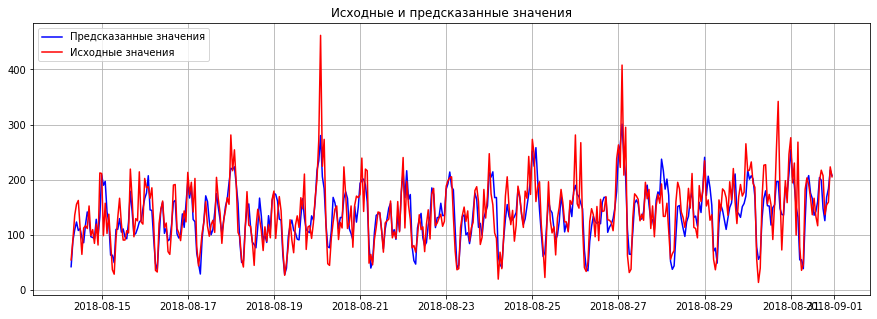

In [189]:
plt.figure(figsize=(15,5))
plt.title('Исходные и предсказанные значения')

plt.plot(y_test.index, y_predict, 'b', label='Предсказанные значения')
plt.plot(y_test.index, y_test.values, 'r', label='Исходные значения')
plt.legend(loc="upper left")
plt.grid(True)

Также сравним нашу модель с методом предсказания по предшествующему значению.

In [191]:
# Сдвигаем тестовый ряд на один шаг назад
y_baseline = y_test.shift()  
# Устанавливаем первое значение прогноза равным последнему значению из обучающей выборки
y_baseline.iloc[0] = y_train.iloc[-1]  

# Вычисляем RMSE для метода предсказания по предшествующему значению
rmse_baseline = mean_squared_error(y_baseline, y_test)**0.5
print("RMSE Базовая модель (предсказание по предшествующему значению):", rmse_baseline)

# Сравнение с RMSE для модели линейной регрессии
rmse_lr = mean_squared_error(y_predict, y_test)**0.5
print("RMSE LinearRegression:", rmse_lr)

# Анализ адекватности модели
if rmse_lr < rmse_baseline:
    print("Модель LinearRegression предсказывает лучше, чем модель предсказания по предшествующему значению")
else:
    print("Модель LinearRegression недостаточно адекватна, т.к. модель предсказания по предыдущему значению дает сравнимые или лучшие результаты.")

RMSE Базовая модель (предсказание по предшествующему значению): 58.819724582830204
RMSE LinearRegression: 34.17820708615267
Модель LinearRegression предсказывает лучше, чем модель предсказания по предшествующему значению


**Выводы**

Лучшей моделью при тестировании является LinearRegression, RMSE = 34.18. Разницу в метрике на train и test выборках можно было ожидать, исходя из графика остатков, она не связана с переобучением модели. 

**Выводы**

Мы получили датасет с данными о заказах такси,

мы ресемплировали его по 1 часу,

мы изучили датасет и пришли к выводу, что он представляет собой монотонный стационарный временной ряд,

мы декомпозировали ряд и выявили сезонность в течение суток, ресемплировали ряд по 1 дню и снова декомпозировали, таким образом выявили и в течение недели, 

мы создали новые признаки времени, лаги и скользящее среднее, количество лагов и новые признаки времени определили исходя из знаний о сезонности: день, день недели, час, 168 лагов, 

обучили модели и подобрали параметры LinearRegression, RandomForestRegressor и CatBoostRegressor на train выборке, оценили, лучшей оказалась LinearRegression,

протестировали лучшую модель на выборке test, RMSE = 34.18, целевой показатель RMSE =< 48, убедились, что выбраннная модель лучше метода предсказания по предшествующему шагу, выбранную модель можно рекомендовать к использованию.